In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
train = pd.read_csv("../data/raw/train.csv")

train.head()

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


In [4]:
train["date"] = pd.to_datetime(train["date"])

weekly = (
    train[train["item"].between(1, 20)]
    .groupby([
        pd.Grouper(key="date", freq="W"),
        "item"
    ])["sales"]
    .sum()
    .reset_index()
    .rename(columns={"sales": "demand"})
)

weekly = weekly.sort_values(["item", "date"]).reset_index(drop=True)

weekly.head()

,date,item,demand
0,2013-01-06,1,802
1,2013-01-13,1,863
2,2013-01-20,1,865
3,2013-01-27,1,799
4,2013-02-03,1,954


In [5]:
import sys
import os

sys.path.append(os.path.abspath(".."))

from src.forecasting.features import create_features

In [6]:
featured = create_features(weekly)

featured.head()

,date,item,demand,lag_1,lag_2,lag_4,lag_8,lag_13,lag_26,lag_52,rolling_mean_4,rolling_std_4,rolling_mean_8,rolling_std_8,rolling_mean_13,rolling_std_13,week_of_year,month,quarter,year
0,2013-01-06,1,802,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1,1,2013
1,2013-01-13,1,863,802.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,1,1,2013
2,2013-01-20,1,865,863.0,802.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,1,1,2013
3,2013-01-27,1,799,865.0,863.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,1,1,2013
4,2013-02-03,1,954,799.0,865.0,802.0,NaN,NaN,NaN,NaN,832.25,36.69128,NaN,NaN,NaN,NaN,5,2,1,2013


In [7]:
import sys
import os

sys.path.append(os.path.abspath(".."))

from src.forecasting.features import create_features

In [8]:
featured = create_features(weekly)

featured.head()

,date,item,demand,lag_1,lag_2,lag_4,lag_8,lag_13,lag_26,lag_52,rolling_mean_4,rolling_std_4,rolling_mean_8,rolling_std_8,rolling_mean_13,rolling_std_13,week_of_year,month,quarter,year
0,2013-01-06,1,802,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1,1,2013
1,2013-01-13,1,863,802.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,1,1,2013
2,2013-01-20,1,865,863.0,802.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,1,1,2013
3,2013-01-27,1,799,865.0,863.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,1,1,2013
4,2013-02-03,1,954,799.0,865.0,802.0,NaN,NaN,NaN,NaN,832.25,36.69128,NaN,NaN,NaN,NaN,5,2,1,2013


In [9]:
print(featured.shape)

(5220, 20)


In [10]:
print(featured.isna().sum())

date                  0
item                  0
demand                0
lag_1                20
lag_2                40
lag_4                80
lag_8               160
lag_13              260
lag_26              520
lag_52             1040
rolling_mean_4       80
rolling_std_4        80
rolling_mean_8      160
rolling_std_8       160
rolling_mean_13     260
rolling_std_13      260
week_of_year          0
month                 0
quarter               0
year                  0
dtype: int64


In [11]:
import importlib
import src.forecasting.features as feature_module

importlib.reload(feature_module)

create_features = feature_module.create_features

In [12]:
featured = create_features(weekly)

print(featured.shape)
print(featured.isna().sum())

(5220, 20)
date                  0
item                  0
demand                0
lag_1                20
lag_2                40
lag_4                80
lag_8               160
lag_13              260
lag_26              520
lag_52             1040
rolling_mean_4       80
rolling_std_4        80
rolling_mean_8      160
rolling_std_8       160
rolling_mean_13     260
rolling_std_13      260
week_of_year          0
month                 0
quarter               0
year                  0
dtype: int64


In [13]:
featured = featured.dropna().reset_index(drop=True)

print(featured.shape)
print(featured.isna().sum().sum())

(4180, 20)
0


In [14]:
cutoff = featured["date"].max() - pd.Timedelta(weeks=26)

train_data = featured[
    featured["date"] <= cutoff
].copy()

test_data = featured[
    featured["date"] > cutoff
].copy()

print("Train:", train_data.shape)
print("Test:", test_data.shape)

print("Train end:", train_data["date"].max())
print("Test start:", test_data["date"].min())
print("Test end:", test_data["date"].max())

Train: (3660, 20)
Test: (520, 20)
Train end: 2017-07-02 00:00:00
Test start: 2017-07-09 00:00:00
Test end: 2017-12-31 00:00:00


In [15]:
feature_cols = [
    col for col in featured.columns
    if col not in ["date", "demand"]
]

X_train = train_data[feature_cols]
y_train = train_data["demand"]

X_test = test_data[feature_cols]
y_test = test_data["demand"]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (3660, 18)
y_train: (3660,)
X_test: (520, 18)
y_test: (520,)


In [16]:
from lightgbm import LGBMRegressor

In [17]:
model_q50 = LGBMRegressor(
    objective="quantile",
    alpha=0.50,
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42
)

In [18]:
model_q50.fit(
    X_train,
    y_train
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000084 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3413
[LightGBM] [Info] Number of data points in the train set: 3660, number of used features: 18
[LightGBM] [Info] Start training from score 3810.500000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


,learning_rate,0.05
,n_estimators,500
,objective,'quantile'
,random_state,42
,alpha,0.5
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,subsample_for_bin,200000
,class_weight,None
,min_split_gain,0.0


In [19]:
pred_q50 = model_q50.predict(X_test)

In [20]:
pred_q50[:10]

array([2277.33724158, 2248.02093969, 2284.675439  , 2281.34341183,
       2112.5983998 , 1926.75137415, 1914.42082293, 1971.61618534,
       1899.92411628, 1818.4331104 ])

In [22]:
def wape(actual, forecast):
    return (
        abs(actual - forecast).sum()
        / abs(actual).sum()
    )

In [23]:
q50_wape = wape(y_test, pred_q50)

print(f"LightGBM q50 WAPE: {q50_wape:.2%}")

LightGBM q50 WAPE: 2.23%


In [24]:
from sklearn.metrics import mean_squared_error
import numpy as np

q50_rmse = np.sqrt(
    mean_squared_error(y_test, pred_q50)
)

print(f"LightGBM q50 RMSE: {q50_rmse:.2f}")

LightGBM q50 RMSE: 138.50


In [25]:
bias = np.mean(pred_q50 - y_test)

print(f"LightGBM q50 Bias: {bias:.2f}")

LightGBM q50 Bias: 43.46


In [26]:
model_q10 = LGBMRegressor(
    objective="quantile",
    alpha=0.10,
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42
)

model_q10.fit(
    X_train,
    y_train
)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000283 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3413
[LightGBM] [Info] Number of data points in the train set: 3660, number of used features: 18
[LightGBM] [Info] Start training from score 1569.900024
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

,learning_rate,0.05
,n_estimators,500
,objective,'quantile'
,random_state,42
,alpha,0.1
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,subsample_for_bin,200000
,class_weight,None
,min_split_gain,0.0


In [27]:
pred_q10 = model_q10.predict(X_test)

pred_q10[:10]

array([2221.54951539, 2107.12753158, 2113.07351642, 2204.19218462,
       1921.01000385, 1899.36835365, 1880.36480568, 1871.08658231,
       1895.74024243, 1784.36090986])

In [28]:
model_q90 = LGBMRegressor(
    objective="quantile",
    alpha=0.90,
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42
)

model_q90.fit(
    X_train,
    y_train
)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000445 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3413
[LightGBM] [Info] Number of data points in the train set: 3660, number of used features: 18
[LightGBM] [Info] Start training from score 6303.199707
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

,learning_rate,0.05
,n_estimators,500
,objective,'quantile'
,random_state,42
,alpha,0.9
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,subsample_for_bin,200000
,class_weight,None
,min_split_gain,0.0


In [29]:
pred_q90 = model_q90.predict(X_test)

pred_q90[:10]

array([2391.77356142, 2320.76742984, 2361.5183825 , 2349.49266118,
       2178.81369165, 2014.03409204, 1975.72132827, 2020.71648953,
       1937.78885751, 1909.37705682])

In [30]:
print("q10 < q50:", np.mean(pred_q10 < pred_q50))
print("q50 < q90:", np.mean(pred_q50 < pred_q90))

q10 < q50: 0.875
q50 < q90: 0.9403846153846154


In [31]:
def pinball_loss(actual, forecast, quantile):
    error = actual - forecast
    
    return np.mean(
        np.maximum(
            quantile * error,
            (quantile - 1) * error
        )
    )

In [32]:
q10_pinball = pinball_loss(
    y_test,
    pred_q10,
    0.10
)

q50_pinball = pinball_loss(
    y_test,
    pred_q50,
    0.50
)

q90_pinball = pinball_loss(
    y_test,
    pred_q90,
    0.90
)

In [33]:
print(f"q10 Pinball Loss: {q10_pinball:.2f}")
print(f"q50 Pinball Loss: {q50_pinball:.2f}")
print(f"q90 Pinball Loss: {q90_pinball:.2f}")

q10 Pinball Loss: 34.27
q50 Pinball Loss: 49.08
q90 Pinball Loss: 23.18


In [34]:
coverage = np.mean(
    (y_test >= pred_q10) &
    (y_test <= pred_q90)
)

print(f"q10-q90 Coverage: {coverage:.2%}")

q10-q90 Coverage: 58.65%


In [35]:
print("Average q10:", pred_q10.mean())
print("Average q50:", pred_q50.mean())
print("Average q90:", pred_q90.mean())

print("Average interval width:", (pred_q90 - pred_q10).mean())

Average q10: 4323.803654981744
Average q50: 4452.432008507957
Average q90: 4581.699738961451
Average interval width: 257.896083979708


In [36]:
below_q10 = np.mean(y_test < pred_q10)
above_q90 = np.mean(y_test > pred_q90)

print(f"Below q10: {below_q10:.2%}")
print(f"Above q90: {above_q90:.2%}")

Below q10: 32.31%
Above q90: 9.04%


In [37]:
print("Average actual:", y_test.mean())
print("Average q10:", pred_q10.mean())
print("Average q50:", pred_q50.mean())
print("Average q90:", pred_q90.mean())

Average actual: 4408.967307692307
Average q10: 4323.803654981744
Average q50: 4452.432008507957
Average q90: 4581.699738961451


In [38]:
print("Average actual - q10:",
      (y_test - pred_q10).mean())

print("Average actual - q90:",
      (y_test - pred_q90).mean())

Average actual - q10: 85.16365271056402
Average actual - q90: -172.73243126914394


In [39]:
forecast_results = test_data[
    ["date", "item", "demand"]
].copy()

forecast_results["q10"] = pred_q10
forecast_results["q50"] = pred_q50
forecast_results["q90"] = pred_q90

forecast_results = forecast_results.rename(
    columns={"demand": "actual_demand"}
)

forecast_results.head()

,date,item,actual_demand,q10,q50,q90
183,2017-07-09,1,2227,2221.549515,2277.337242,2391.773561
184,2017-07-16,1,2261,2107.127532,2248.020940,2320.767430
185,2017-07-23,1,2239,2113.073516,2284.675439,2361.518382
186,2017-07-30,1,2247,2204.192185,2281.343412,2349.492661
187,2017-08-06,1,1947,1921.010004,2112.598400,2178.813692


In [40]:
import os

os.makedirs("../data/processed", exist_ok=True)

forecast_results.to_csv(
    "../data/processed/forecast_results.csv",
    index=False
)

print("Saved successfully!")

Saved successfully!


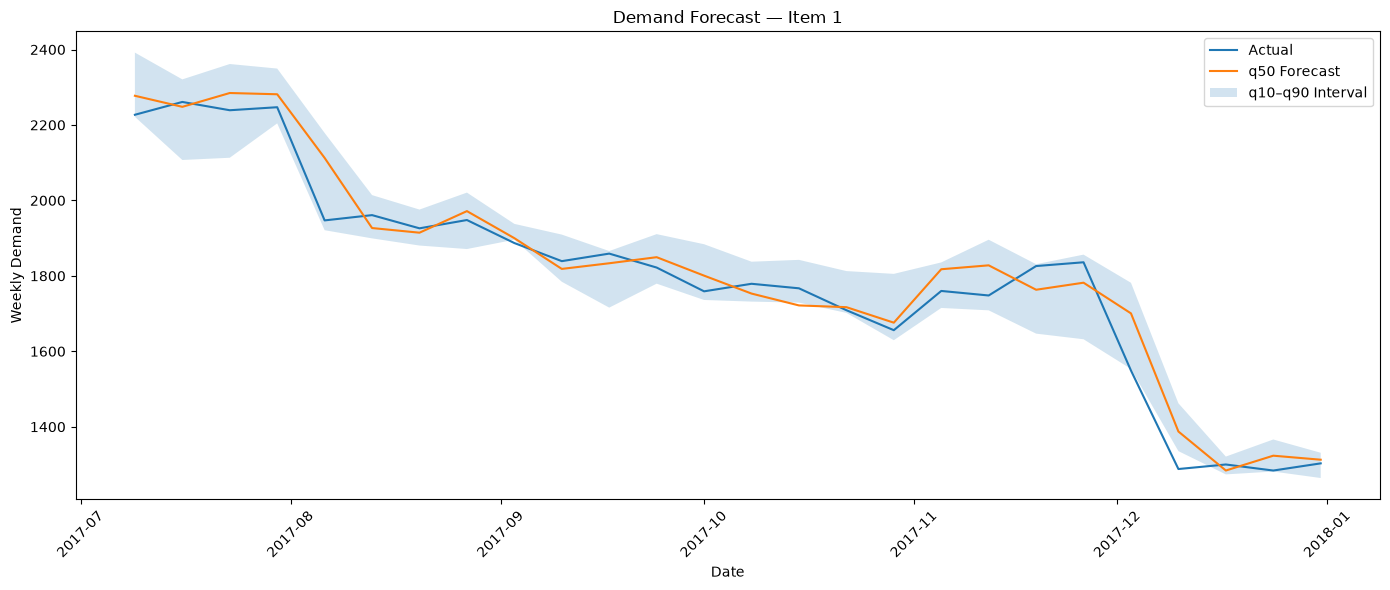

In [41]:
import matplotlib.pyplot as plt

item_1 = forecast_results[
    forecast_results["item"] == 1
].sort_values("date")

plt.figure(figsize=(14, 6))

plt.plot(
    item_1["date"],
    item_1["actual_demand"],
    label="Actual"
)

plt.plot(
    item_1["date"],
    item_1["q50"],
    label="q50 Forecast"
)

plt.fill_between(
    item_1["date"],
    item_1["q10"],
    item_1["q90"],
    alpha=0.2,
    label="q10–q90 Interval"
)

plt.xlabel("Date")
plt.ylabel("Weekly Demand")
plt.title("Demand Forecast — Item 1")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()